In [1]:
import socket
import threading

In [2]:
clients = []
names = {}


In [3]:
def broadcast(message, sender=None):
    for client in clients:
        if client != sender:
            client.send(message)

In [4]:
def handle_client(c):
    while True:
        try:
            msg = c.recv(1024).decode()

            if msg.lower().endswith("exit"):
                name = names[c]
                broadcast(f"{name} left the chat".encode(), c)
                clients.remove(c)
                del names[c]
                c.close()
                break

            broadcast(msg.encode(), c)

        except:
            if c in clients:
                clients.remove(c)
            c.close()
            break


In [5]:
s = socket.socket()
print("Socket created")

Socket created


In [6]:
s.bind(('localhost',9999))
s.listen(5)
print("Chat server started...")
print("Waiting for cleint connection")

Chat server started...
Waiting for cleint connection


In [ ]:
while True:
    c, addr = s.accept()

    name = c.recv(1024).decode()

    clients.append(c)
    names[c] = name

    print(name, "connected")

    broadcast(f"{name} joined the chat".encode())

    threading.Thread(target=handle_client, args=(c,), daemon=True).start()


rayyan connected
malik connected
arham connected


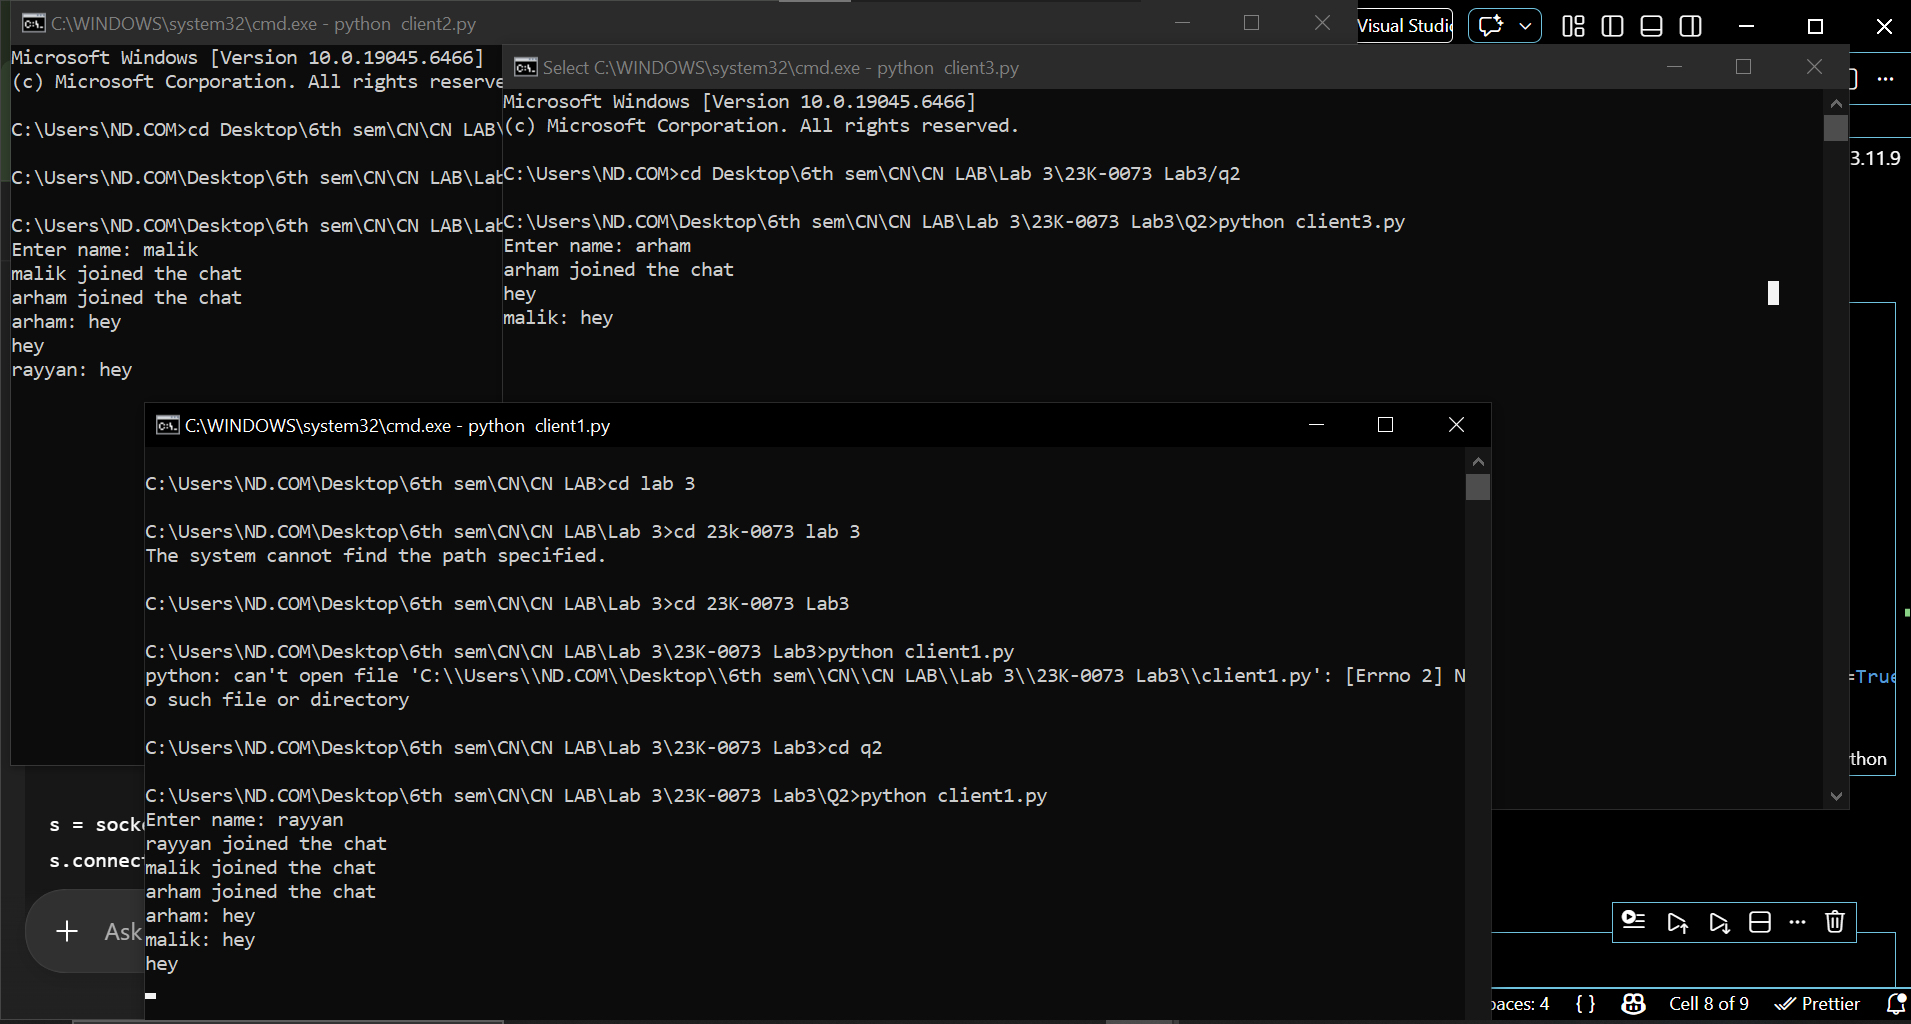
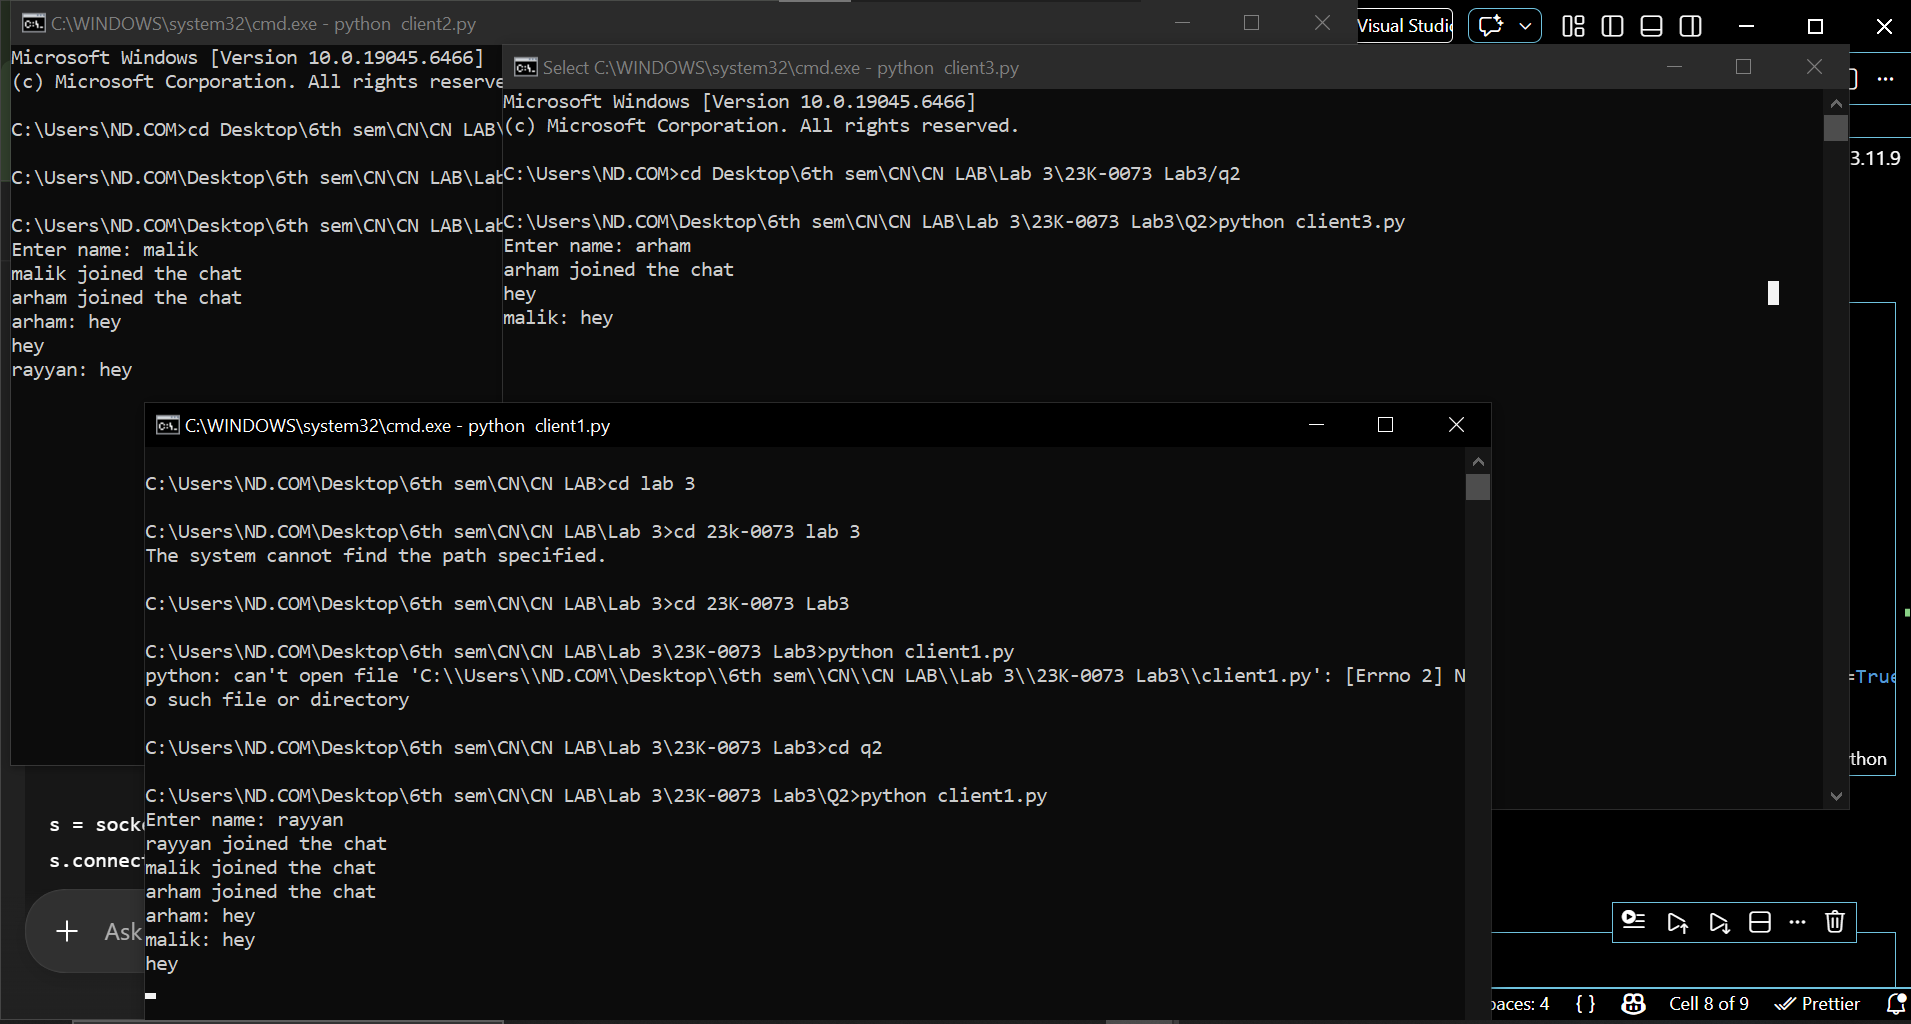